# Cluster label optimization

Select the Leiden resolution whose partition best aligns with the `cell_type` weak prior, scored via a **Jaccard / Hungarian** matching procedure: for each resolution, a contingency table between Leiden clusters and cell types is converted to an IoU (Jaccard) matrix, the optimal one-to-one assignment is found with the Hungarian algorithm, and the summed matched Jaccard score is normalised by a denominator that penalises over-clustering when the number of clusters exceeds `k_prior`.

Cells with a `cell_type` label that appears fewer than `MIN_CELLS_PER_TYPE` times are excluded before scoring, keeping the prior reliable.

In [67]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from numpy.typing import NDArray
from scipy.optimize import linear_sum_assignment
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import silhouette_score
from sklearn.metrics import homogeneity_score
from sklearn.metrics import completeness_score
from sklearn.metrics import v_measure_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

sc.set_figure_params(dpi=100, facecolor="white")

SUMMARY_PATH = Path("datasets_summary")
dataset_catalog = pd.read_csv(SUMMARY_PATH).sort_values("quantile").reset_index(drop=True)
# Pick one row: set SRX_ACCESSION to a value from the catalog, or leave None and use DATASET_INDEX.
SRX_ACCESSION: str | None = None
DATASET_INDEX = 2

LOCAL_H5AD_ROOT = Path("../data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens")


def select_dataset_row(df: pd.DataFrame) -> pd.Series:
    if SRX_ACCESSION is not None:
        hit = df.loc[df["srx_accession"] == SRX_ACCESSION]
        if hit.empty:
            raise ValueError(
                f"srx_accession {SRX_ACCESSION!r} not in {SUMMARY_PATH}; "
                f"choices: {df['srx_accession'].tolist()}"
            )
        return hit.iloc[0]
    idx = int(DATASET_INDEX)
    if idx < 0 or idx >= len(df):
        raise IndexError(
            f"DATASET_INDEX {idx} out of range for {len(df)} rows in {SUMMARY_PATH}"
        )
    return df.iloc[idx]


dataset_row = select_dataset_row(dataset_catalog)
DATASET_SRX = str(dataset_row["srx_accession"])
DATASET_FILE_PATH = str(dataset_row["file_path"])
DATASET_QUANTILE = float(dataset_row["quantile"])
DATASET_TAG = DATASET_SRX
local_h5ad_path = LOCAL_H5AD_ROOT / f"{DATASET_SRX}.h5ad"
DATASET_TITLE_SUFFIX = f"{DATASET_SRX} (quantile={DATASET_QUANTILE})"


def load_adata_h5ad() -> sc.AnnData:
    if local_h5ad_path.exists():
        return sc.read(local_h5ad_path)
    return sc.read(DATASET_FILE_PATH)

MIN_CELLS_PER_TYPE = 20 # TODO: this is the big parameter--really affects results. look into this
N_TOP_GENES = 2000
# PCA / neighbours: compute enough PCs for the scree, then pick n_pcs based on cumulative variance target.
N_PCS_COMPUTE = 50
N_PCS_MIN = 15
N_PCS_CUMVAR_TARGET = 0.5
RESOLUTIONS = np.round(np.arange(0.1, 2.0, 0.1), 1)
MERGE_THRESHOLD = 0.2  # lower → more merges; tune toward k_prior
# If True, RF fit uses inverse cell_type frequency as sample_weight (weak prior); False = old behaviour
RF_BALANCE_WEAK_PRIOR = False  # TODO: delete this part of the methods

SAVE_FIGS = False

def _save_fig(fig, path: str | Path, **kwargs) -> None:
    if SAVE_FIGS:
        fig.savefig(path, **kwargs)

## 1. Load & filter rare cell types

### 1.1 Load

In [68]:
adata = load_adata_h5ad()
adata.obs_names_make_unique()
print(
    f"Loaded {adata.n_obs} cells — {DATASET_SRX} from "
    f"{local_h5ad_path if local_h5ad_path.exists() else DATASET_FILE_PATH}"
)

Loaded 5506 cells — SRX17412841 from ../data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens/SRX17412841.h5ad


In [69]:
adata.obs["cell_type"].value_counts()

cell_type
macrophage                              2895
CD4-positive, alpha-beta T cell          657
lung multiciliated epithelial cell       549
B cell                                   394
classical monocyte                       198
intermediate monocyte                    190
respiratory tract goblet cell            160
plasma cell                               98
adventitial cell                          68
club cell                                 57
basal cell                                44
pulmonary alveolar type 2 cell            33
CD8-positive, alpha-beta T cell           28
vein endothelial cell                     26
basophil                                  19
capillary endothelial cell                17
pulmonary alveolar type 1 cell            17
endothelial cell of artery                13
                                          11
endothelial cell of lymphatic vessel      11
natural killer cell                        6
monocyte                                   4


### 1.2 QC

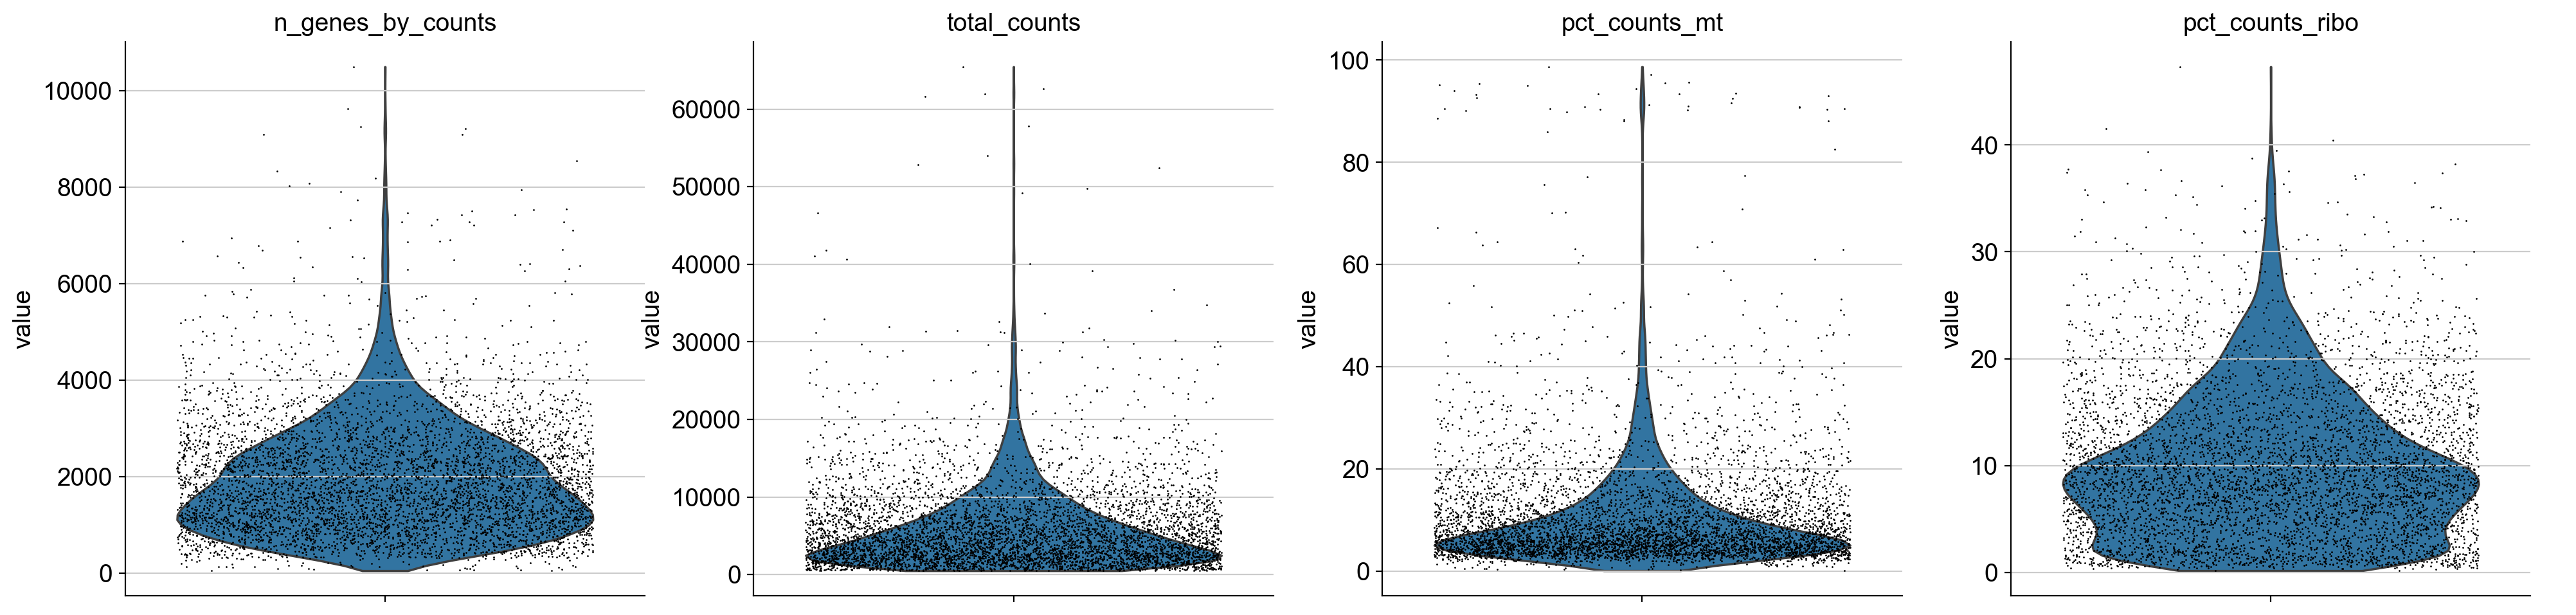

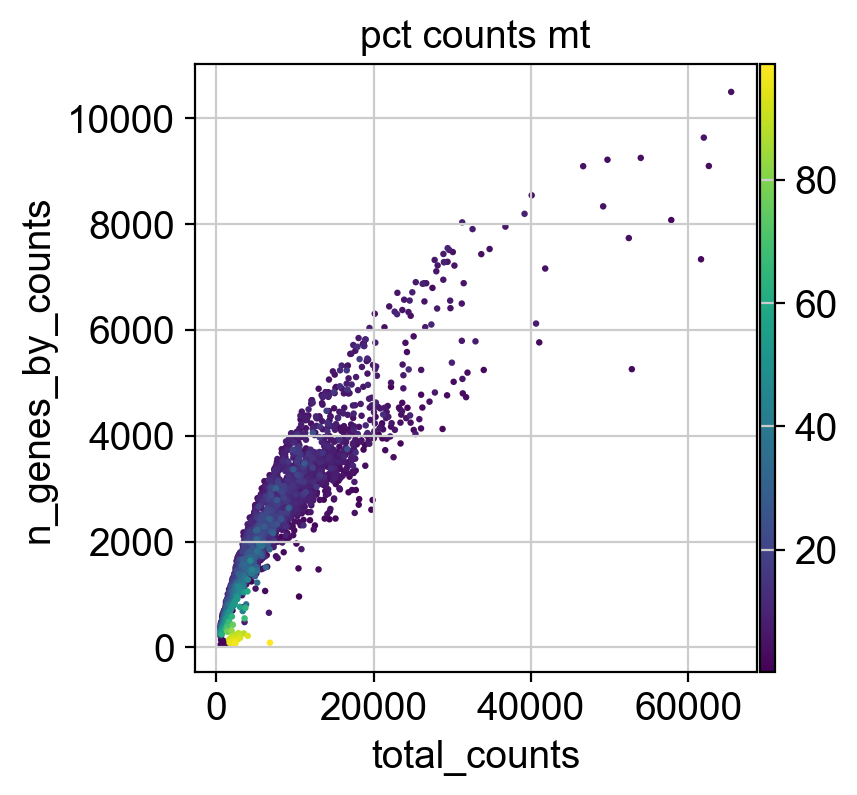

In [70]:
adata.var["mt"] = adata.var["gene_symbols"].str.startswith("MT-")
adata.var["ribo"] = adata.var["gene_symbols"].str.match(r"^RP[SL]\d")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
plt.show()

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", show=False)
plt.show()

### 1.3 Filter

In [71]:
# Save initial statistics
n_cells_original = adata.n_obs
k_prior = adata.obs["cell_type"].nunique()

# Filter by gene/cell and cell/gene counts
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()

# Filter by cell type counts
type_counts = adata.obs["cell_type"].value_counts()
valid_types = type_counts[type_counts >= MIN_CELLS_PER_TYPE].index
mask = adata.obs["cell_type"].isin(valid_types)
adata = adata[mask].copy()

print(adata)

AnnData object with n_obs × n_vars = 4757 × 24280
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


### 1.4 Normalize

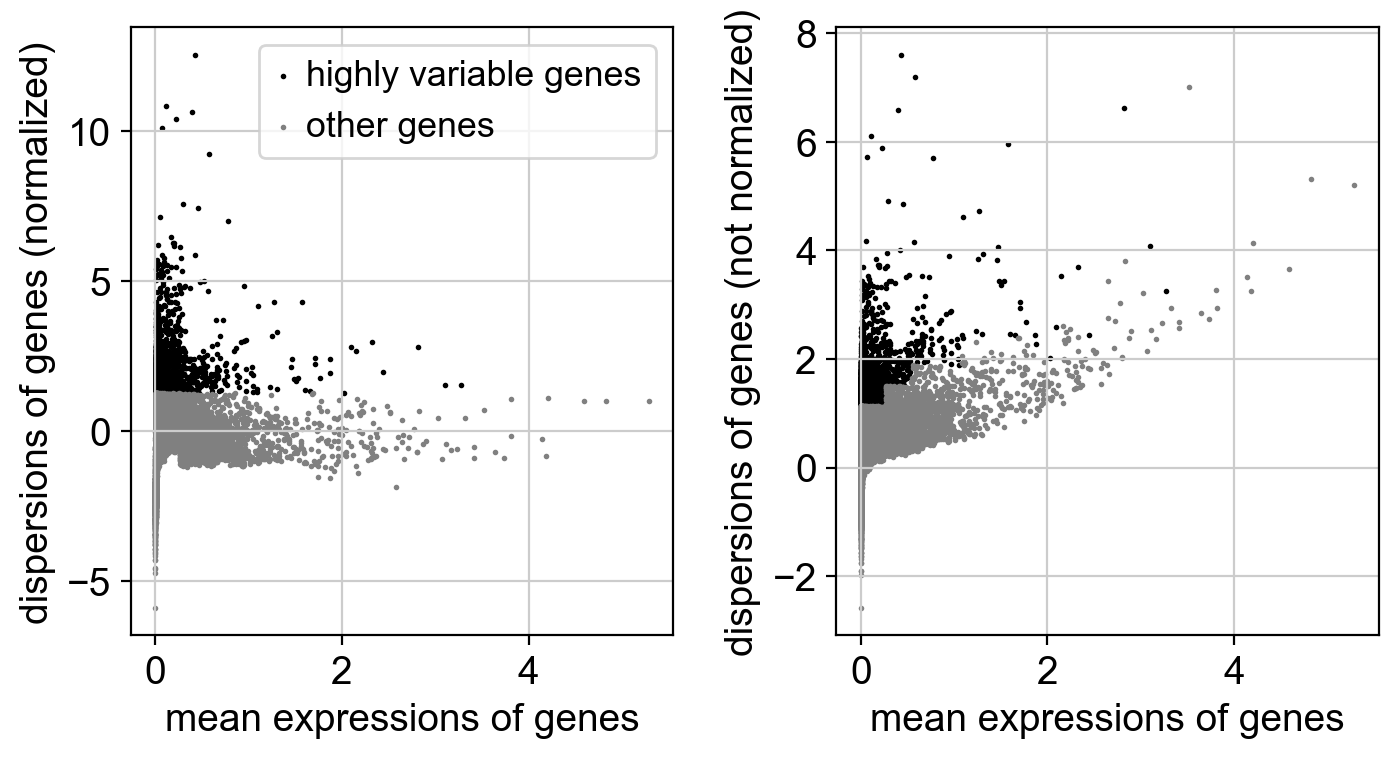

In [72]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_GENES)
sc.pl.highly_variable_genes(adata, show=False)
plt.show()

k_filtered = adata.obs["cell_type"].nunique()
n_dropped = n_cells_original - adata.n_obs 

### Summary

In [73]:
print(
    f"Dropped  : {n_dropped} cells ({n_dropped / len(mask):.1%})  "
    f"from types with < {MIN_CELLS_PER_TYPE} cells"
)
print(f"Remaining: {adata.n_obs} cells,  {k_filtered} cell types  (k_prior = {k_prior})")
print("\nExcluded types:")
print(type_counts[type_counts < MIN_CELLS_PER_TYPE].to_string())

Dropped  : 749 cells (15.4%)  from types with < 20 cells
Remaining: 4757 cells,  14 cell types  (k_prior = 26)

Excluded types:
cell_type
basophil                                18
pulmonary alveolar type 1 cell          17
capillary endothelial cell              15
endothelial cell of artery              13
                                        11
endothelial cell of lymphatic vessel    11
natural killer cell                      6
monocyte                                 4
bronchial smooth muscle cell             4
mature NK T cell                         3
alveolar adventitial fibroblast          3
non-classical monocyte                   1


## 2. Dimensionality reduction

In [74]:
# Run PCA
sc.tl.pca(adata, n_comps=N_PCS_COMPUTE, svd_solver="arpack")

18 PCs make up 50.41% of variance


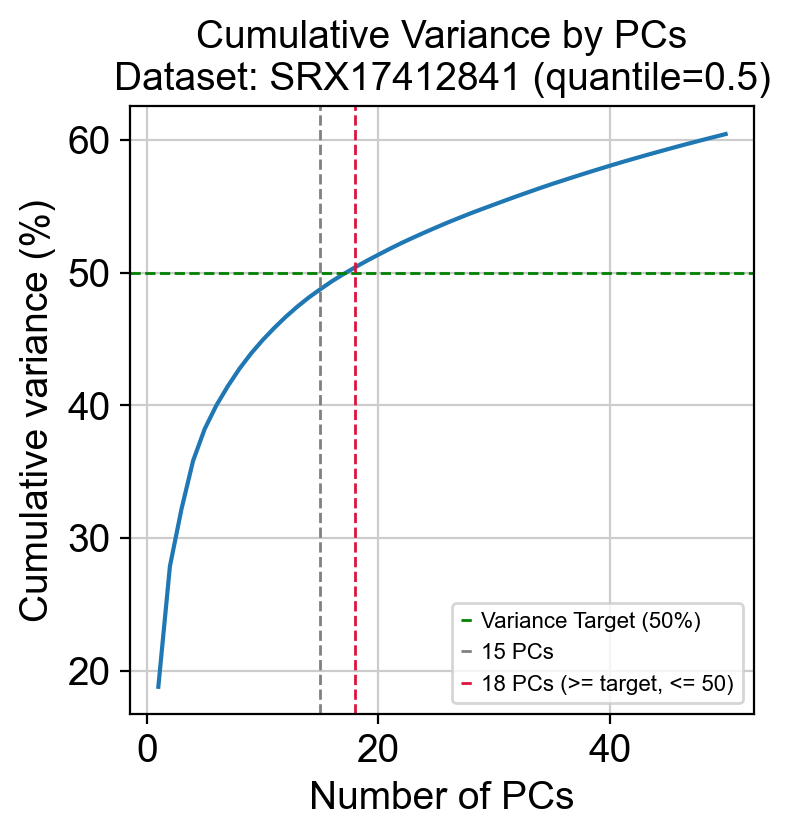

In [75]:
# Determine number of PCs to use based on cumulative variance target
min_pcs_cumvar = np.sum(adata.uns["pca"]["variance_ratio"][:N_PCS_MIN])

if min_pcs_cumvar >= N_PCS_CUMVAR_TARGET:
    N_PCS = 15
    CUMVAR = min_pcs_cumvar * 100
else:
    for i, cumvar_raw in enumerate(np.cumsum(adata.uns["pca"]["variance_ratio"][N_PCS_MIN:]), start=N_PCS_MIN):
        cumvar = cumvar_raw + min_pcs_cumvar
        if cumvar >= N_PCS_CUMVAR_TARGET or i == N_PCS_COMPUTE - 1:
            N_PCS = i + 1
            CUMVAR = cumvar * 100
            break

# Print summary and plot
print(f"{N_PCS} PCs make up {CUMVAR:.2f}% of variance")
fig, ax = plt.subplots()
plt.title(f"Cumulative Variance by PCs\nDataset: {DATASET_TITLE_SUFFIX}")
ax.plot(range(1, len(adata.uns["pca"]["variance_ratio"]) + 1), np.cumsum(adata.uns["pca"]["variance_ratio"]) * 100)
# ax.set_ylim(0, 100)
# ax.set_yticks(np.arange(0, 101, 10))
ax.axvline(N_PCS_MIN, color="gray", linestyle="--", linewidth=1)
ax.axhline(N_PCS_CUMVAR_TARGET * 100, color="green", linestyle="--", linewidth=1)
ax.axvline(N_PCS, color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel("Number of PCs")
ax.set_ylabel("Cumulative variance (%)")
legend_lines = []
legend_labels = []

legend_lines.append(plt.Line2D([0], [0], color="green", linestyle="--", linewidth=1))
legend_labels.append(f"Variance Target ({int(N_PCS_CUMVAR_TARGET * 100)}%)")

if N_PCS > N_PCS_MIN:
    legend_lines.append(plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1))
    legend_labels.append("15 PCs")

legend_lines.append(plt.Line2D([0], [0], color="crimson", linestyle="--", linewidth=1))
legend_labels.append(f"{N_PCS} PCs (>= target, <= {N_PCS_COMPUTE})")

plt.legend(
    legend_lines,
    legend_labels,
    loc=4,
    fontsize=8,
)
# ax.axhline(N_PCS_CUMVAR_TARGET * 100, color="crimson", linestyle="--", linewidth=1)
_save_fig(fig, f".figs/pca_cumvar_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

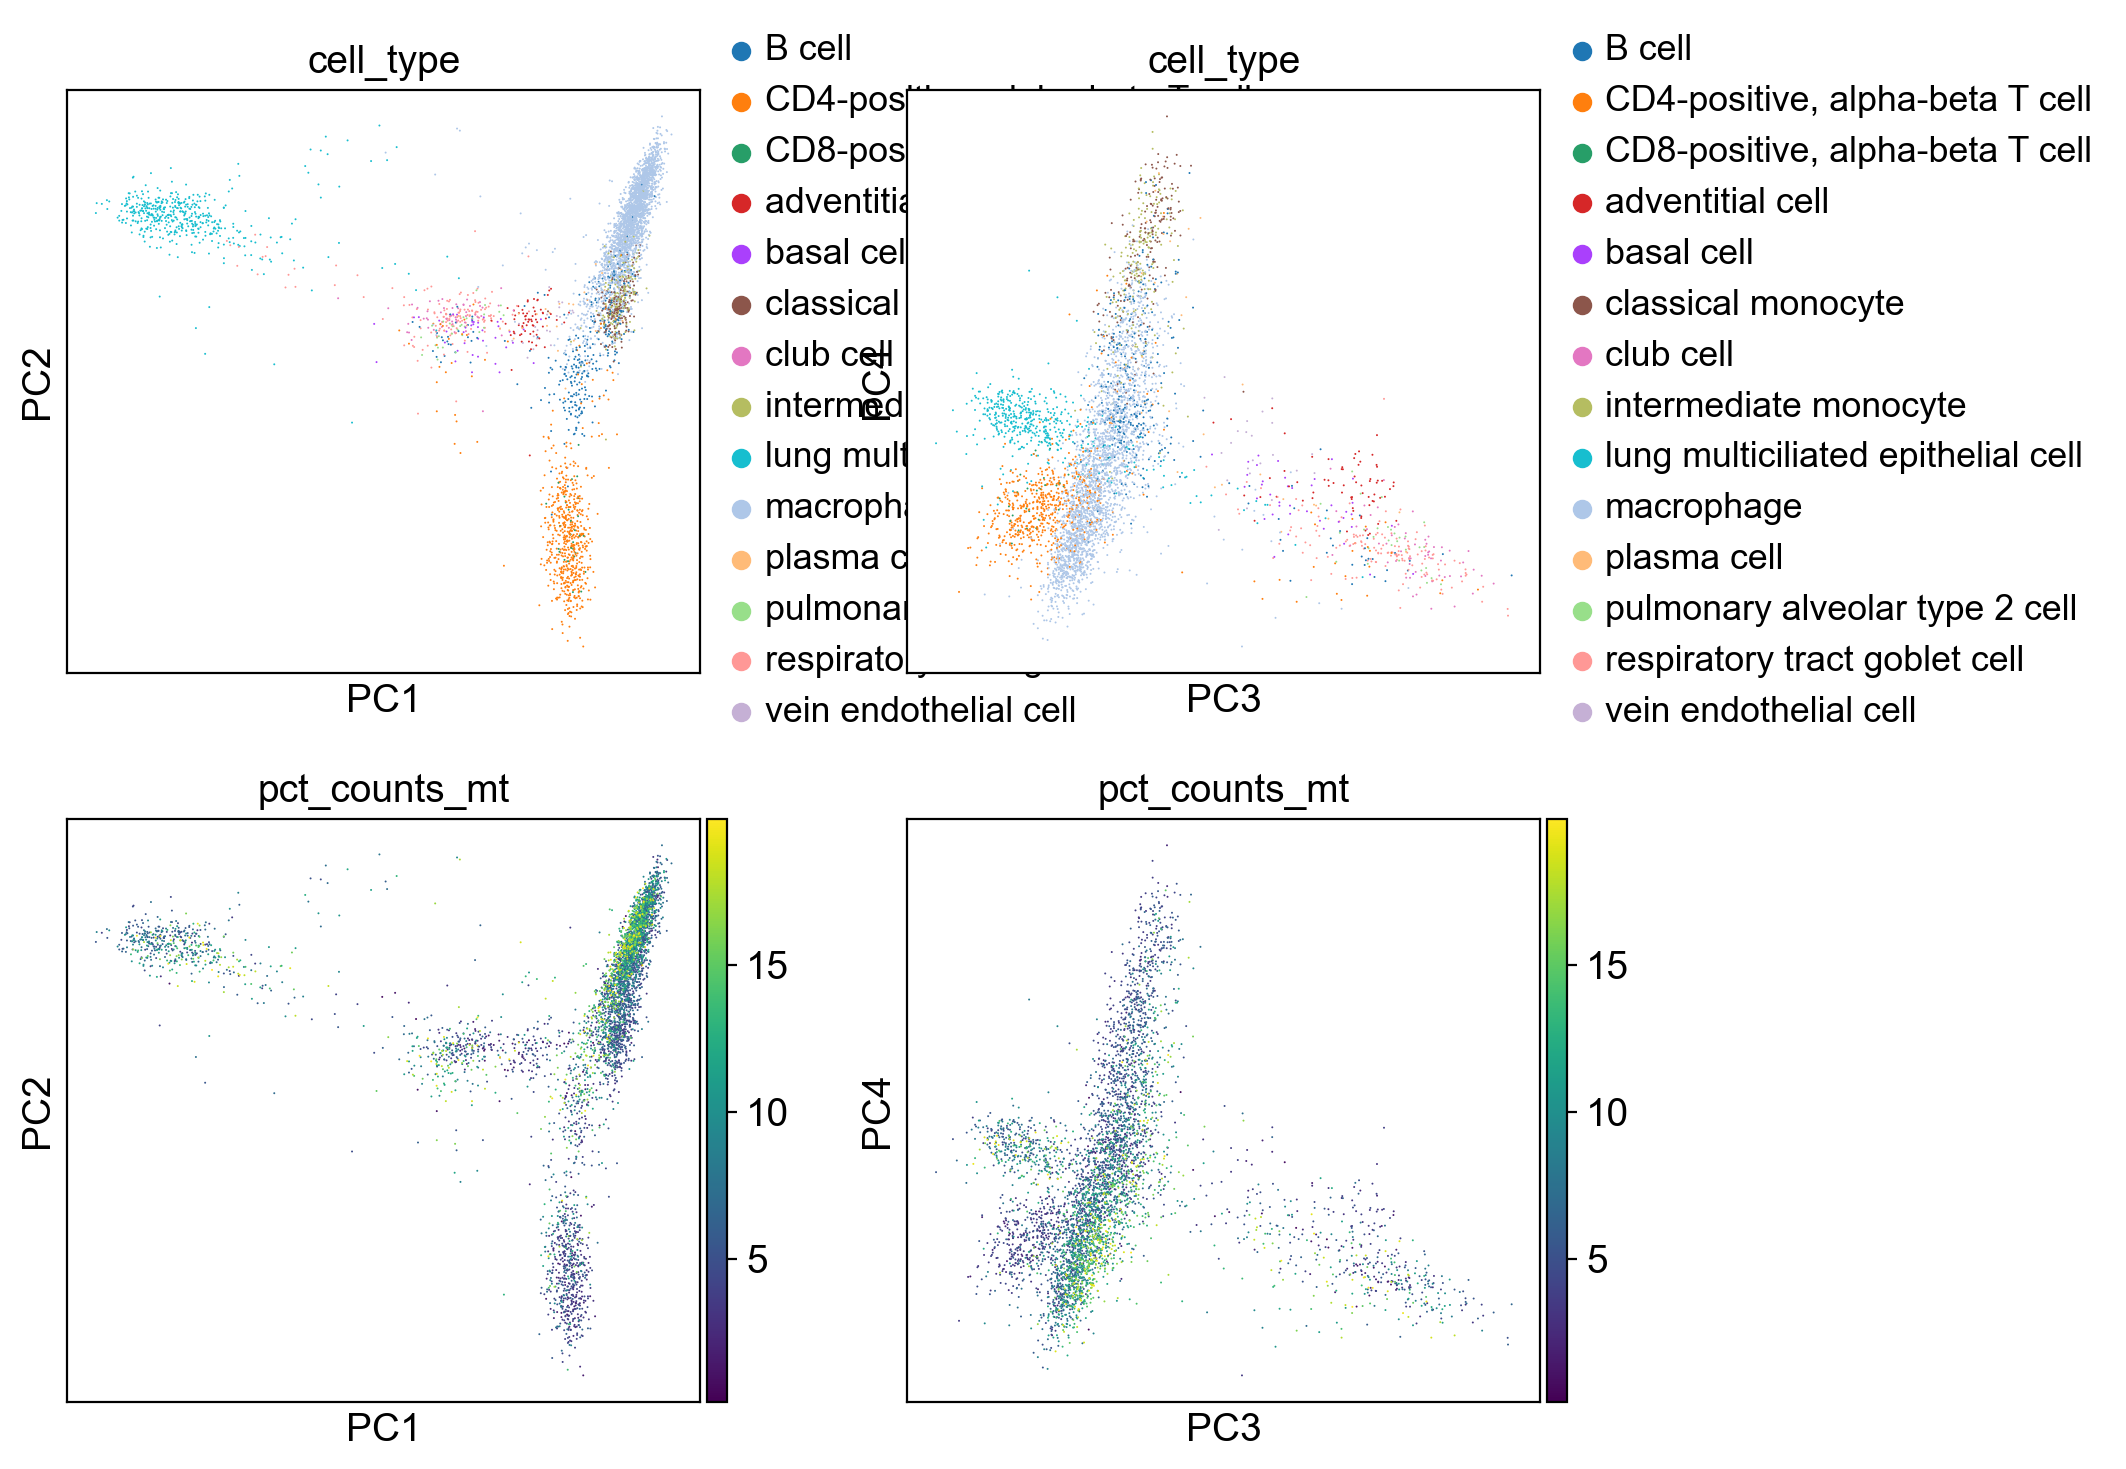

In [76]:
sc.pl.pca(
    adata,
    color=["cell_type", "cell_type", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [77]:
# Run UMAP (local neighborhood = 15 data points)
sc.pp.neighbors(adata, n_pcs=N_PCS)
sc.tl.umap(adata)

## 3. Resolution sweep

In [78]:
for r in RESOLUTIONS:
    sc.tl.leiden(
        adata, resolution=r, flavor="igraph",
        n_iterations=2, directed=False, key_added=f"leiden_{r}",
    )

n_clusters = {r: adata.obs[f"leiden_{r}"].nunique() for r in RESOLUTIONS}

print(f"k_prior: {k_prior}\n")
print(pd.Series(n_clusters, name="n_clusters").to_string())

k_prior: 26

0.1     6
0.2     7
0.3     8
0.4     9
0.5     9
0.6    10
0.7    13
0.8    15
0.9    16
1.0    17
1.1    17
1.2    18
1.3    19
1.4    20
1.5    19
1.6    22
1.7    22
1.8    23
1.9    26


## 4. Jaccard-based resolution selection

For each resolution, every Leiden cluster is optimally matched 1-to-1 to a cell type using the Hungarian algorithm on the Jaccard similarity matrix. The resolution score is the sum of matched Jaccard values divided by `max(k, k_prior)`.

| Step | Operation |
|---|---|
| 1 | Build contingency table `C[i, j]` = cells in cluster `i` with `cell_type` `j` |
| 2 | Compute `J[i, j] = C[i,j] / (\|cluster_i\| + \|celltype_j\| - C[i,j])` |
| 3 | Optimal 1-to-1 matching via `linear_sum_assignment(-J)` |
| 4 | `score = sum(matched J) / max(k, k_prior)` |

The denominator penalises both extremes: under-clustering (k < k_prior) leaves cell types unmatched; over-clustering (k > k_prior) leaves clusters unmatched. Both pull the score toward zero. The optimum is the resolution where clusters align 1-to-1 with cell types in size and composition.

In [79]:
# Get reference labels (one per cell)
ref_labels = adata.obs["cell_type"].values
# Get unique cell types
celltypes = np.unique(ref_labels)
# Get number of clusters for each resolution
k_arr = np.array([n_clusters[r] for r in RESOLUTIONS])
# Initialise array to store Jaccard scores
jacc_arr = np.zeros(len(RESOLUTIONS))
sil_arr = np.full(len(RESOLUTIONS), np.nan)

# Loop through resolutions
for idx, r in enumerate(RESOLUTIONS):
    # Get Leiden labels for current resolution (one per cell)
    leiden_labels = adata.obs[f"leiden_{r}"].values
    # Get unique clusters for current resolution
    clusters = np.unique(leiden_labels)
    # Get number of clusters and cell types
    k, m = len(clusters), len(celltypes)

    # Create mapping of cluster indices to cluster labels and cell type indices to cell type labels
    cl_idx = {c: i for i, c in enumerate(clusters)}
    ct_idx = {t: j for j, t in enumerate(celltypes)}

    # Create contingency table
    C = np.zeros((k, m), dtype=np.float64)
    # Populate contingency table
    for cl, ct in zip(leiden_labels, ref_labels):
        # Increment cell count in contingency table where cluster and cell type meet (intersection)
        C[cl_idx[cl], ct_idx[ct]] += 1

    # Get size of each cluster and cell type
    cl_sizes = C.sum(axis=1)
    ct_sizes = C.sum(axis=0)
    # Compute Jaccard similarity matrix (IoU), prevent division by zero
    J = C / (cl_sizes[:, None] + ct_sizes[None, :] - C + 1e-10)

    # Optimal 1-to-1 matching via Hungarian algorithm (minimize cost: more negative = better)
    row_ind, col_ind = linear_sum_assignment(-J)
    # Sum of Jaccard values of optimal matches
    jacc_arr[idx] = J[row_ind, col_ind].sum()

best_idx = int(np.argmax(jacc_arr))
SELECTED_RESOLUTION = RESOLUTIONS[best_idx]
CLUSTER_KEY = f"leiden_{SELECTED_RESOLUTION}"

print(
    f"Selected resolution : {SELECTED_RESOLUTION}\n"
    f"Clusters (k)        : {n_clusters[SELECTED_RESOLUTION]}\n"
    f"k_prior             : {k_prior}\n"
    f"Jaccard score       : {jacc_arr[best_idx]:.3f}"
)

Selected resolution : 1.5
Clusters (k)        : 19
k_prior             : 26
Jaccard score       : 4.594


### 4.1 Plot Jaccard

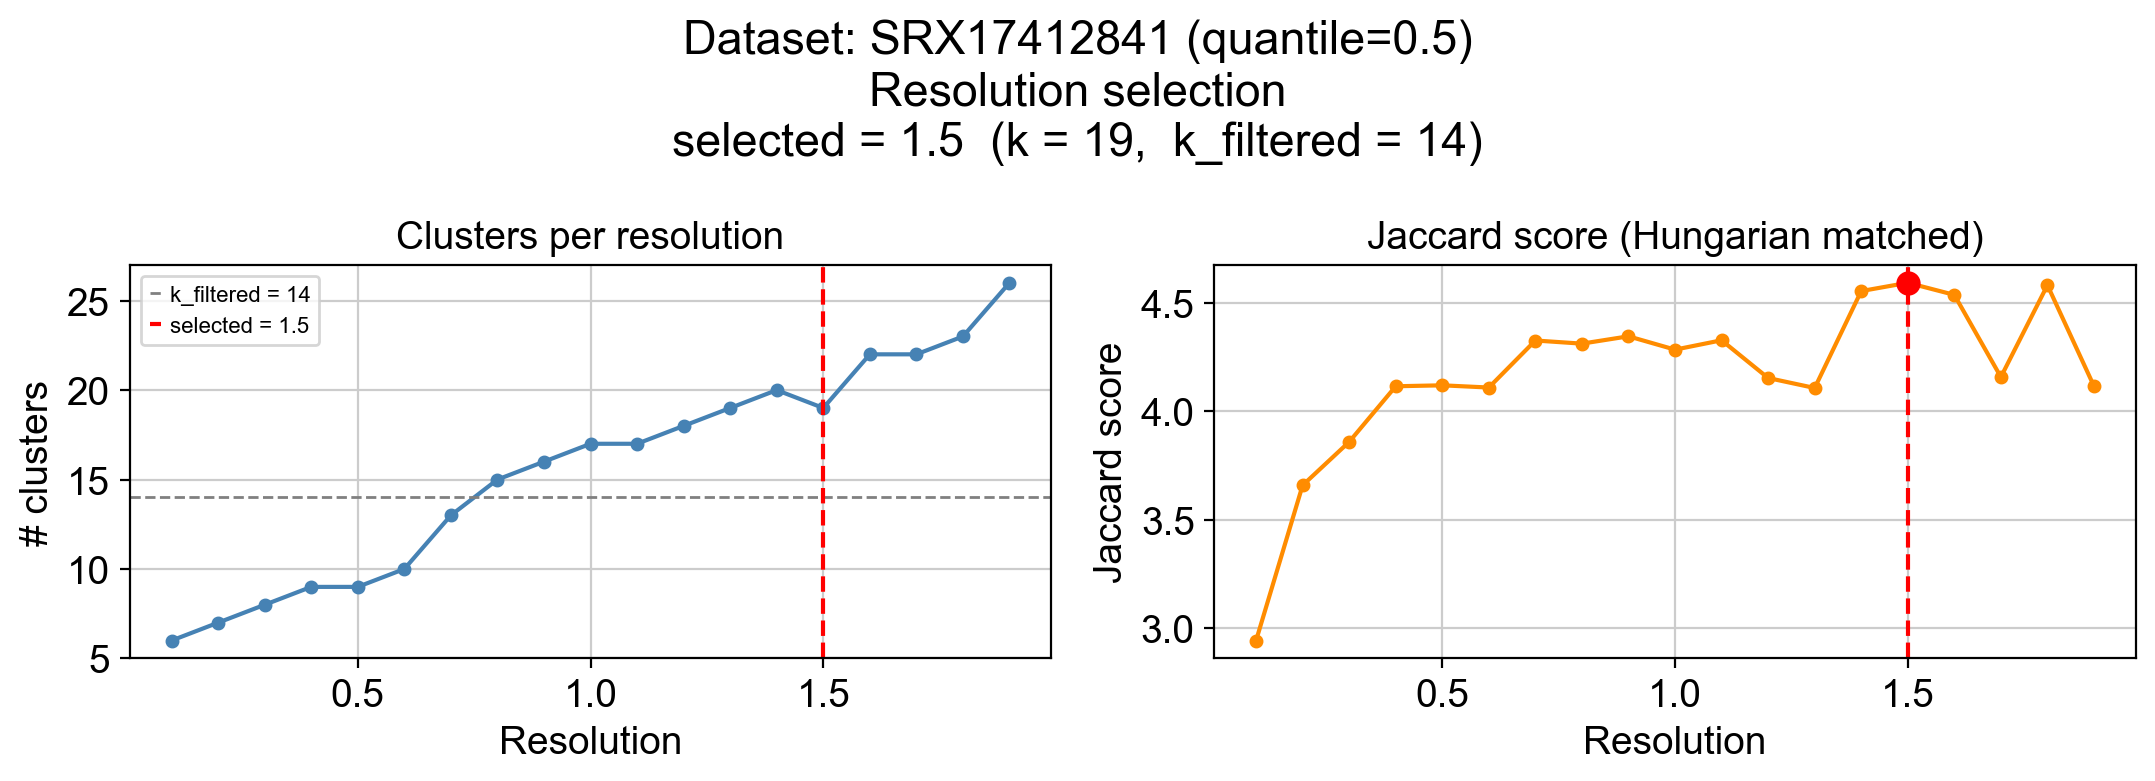

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# panel 1 — k vs resolution
axes[0].plot(RESOLUTIONS, k_arr, marker="o", ms=4, color="steelblue")
axes[0].axhline(k_filtered, color="gray", linestyle="--", linewidth=1,
                label=f"k_filtered = {k_filtered}")
axes[0].axvline(SELECTED_RESOLUTION, color="red", linestyle="--",
                label=f"selected = {SELECTED_RESOLUTION}")
axes[0].set_xlabel("Resolution")
axes[0].set_ylabel("# clusters")
axes[0].set_title("Clusters per resolution")
axes[0].legend(fontsize=8)

# panel 2 — Jaccard
ax_j = axes[1]
(line_j,) = ax_j.plot(
    RESOLUTIONS, jacc_arr, marker="o", ms=4, color="darkorange", label="Jaccard",
)
ax_j.axvline(SELECTED_RESOLUTION, color="red", linestyle="--",
             label=f"argmax = {SELECTED_RESOLUTION}")
ax_j.scatter(
    [SELECTED_RESOLUTION], [jacc_arr[best_idx]],
    color="red", zorder=5, s=60,
)
ax_j.set_xlabel("Resolution")
ax_j.set_ylabel("Jaccard score")
ax_j.tick_params(axis="y")
ax_j.set_title("Jaccard score (Hungarian matched)")

plt.suptitle(
    f"Dataset: {DATASET_TITLE_SUFFIX}\nResolution selection\nselected = {SELECTED_RESOLUTION}  "
    f"(k = {n_clusters[SELECTED_RESOLUTION]},  k_filtered = {k_filtered})",
    # fontsize=10,
)
plt.tight_layout()
_save_fig(fig, f".figs/resolution_sweep_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

## 5. Visualise selected partition

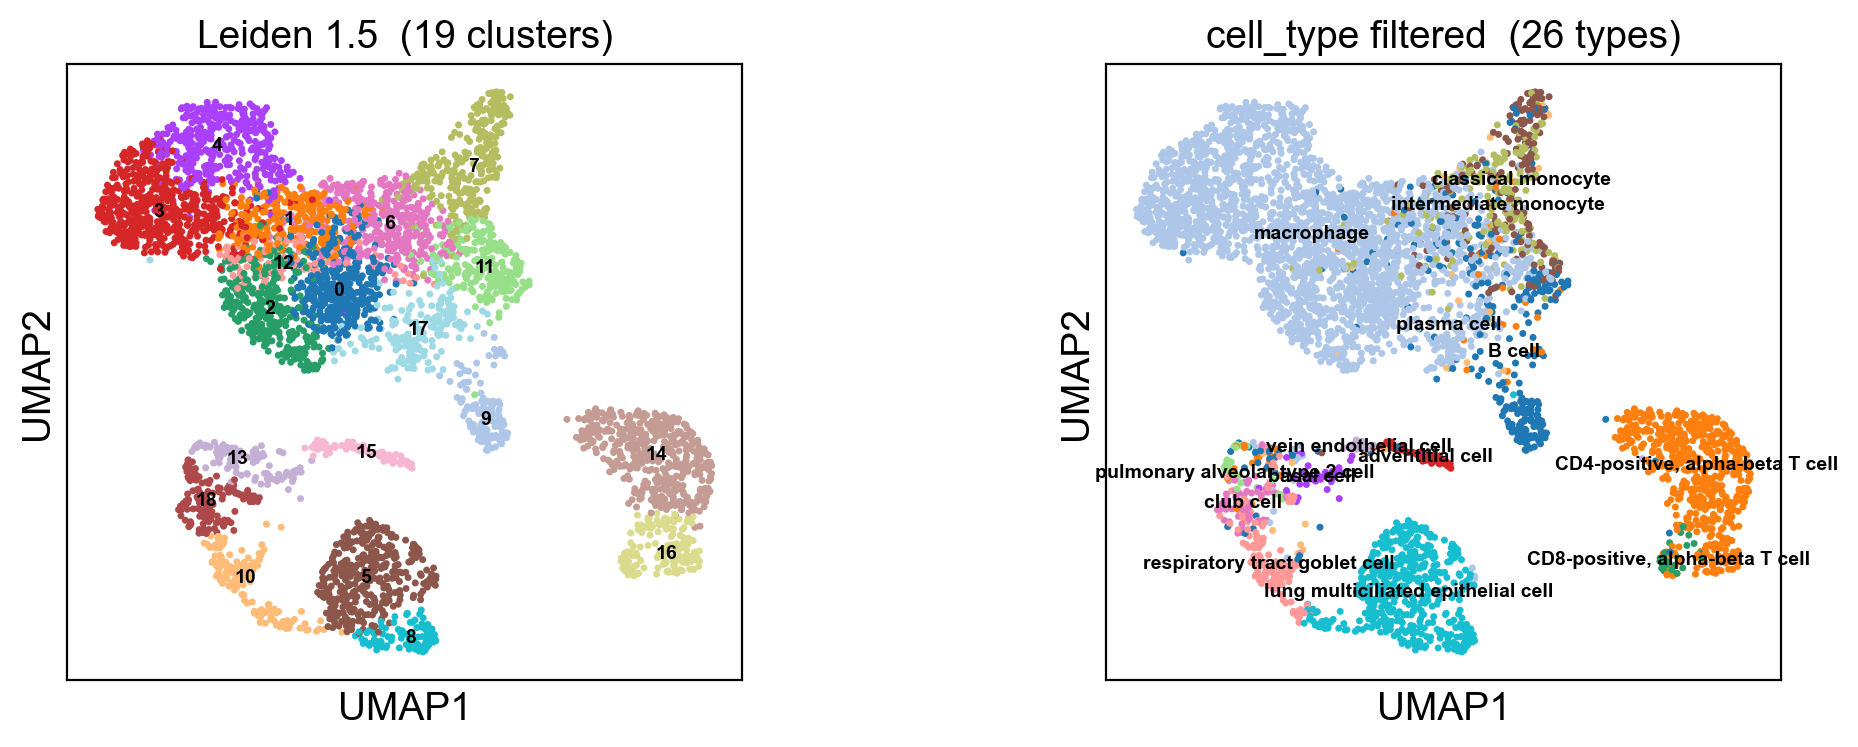

In [81]:
sc.pl.umap(
    adata,
    color=[CLUSTER_KEY, "cell_type"],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
    title=[
        f"Leiden {SELECTED_RESOLUTION}  ({n_clusters[SELECTED_RESOLUTION]} clusters)",
        f"cell_type filtered  ({k_prior} types)",
    ],
    show=False,
)
plt.show()

## 6. RF-based cluster merging

Use this section when the selected Leiden partition is still over-clustered relative to the biological signal. A `RandomForestClassifier` is trained on the selected partition using stratified out-of-fold CV. The row-normalised OOF confusion matrix identifies cluster pairs that are transcriptomically indistinguishable; those pairs are merged via union-find (transitively: if A↔B and B↔C, all three collapse).

Tune `MERGE_THRESHOLD` to adjust the final cluster count toward `k_prior`.

In [82]:
# Define functions
def rf_pairwise_confusion(
    X: NDArray[np.float32],
    cluster_labels: NDArray[np.str_],
    n_estimators: int = 300,
    n_splits: int = 3,
    random_state: int = 42,
    weak_prior_labels: NDArray | None = None,
) -> tuple[NDArray[np.float64], NDArray]:
    le = LabelEncoder()
    y = le.fit_transform(cluster_labels)
    n_classes = len(le.classes_)
    min_class_size = int(np.bincount(y).min())
    n_splits = min(n_splits, min_class_size)

    w_full: NDArray[np.float64] | None = None
    if weak_prior_labels is not None:
        s = pd.Series(np.asarray(weak_prior_labels))
        vc = s.value_counts(dropna=False)
        cnt = s.map(vc).replace(0, 1).astype(float)
        w_full = (1.0 / cnt).to_numpy(dtype=np.float64)
        w_full *= len(w_full) / w_full.sum()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in skf.split(X, y):
        rf = RandomForestClassifier(
            n_estimators=n_estimators, n_jobs=-1, random_state=random_state
        )
        if w_full is None:
            rf.fit(X[train_idx], y[train_idx])
        else:
            rf.fit(
                X[train_idx],
                y[train_idx],
                sample_weight=w_full[train_idx],
            )
        oof_preds[test_idx] = rf.predict(X[test_idx])

    conf = np.zeros((n_classes, n_classes))
    for true, pred in zip(y, oof_preds):
        conf[true, pred] += 1
    row_sums = conf.sum(axis=1, keepdims=True)
    conf = conf / np.where(row_sums == 0, 1, row_sums)

    return conf, le.classes_


def merge_by_confusion(
    cluster_labels: NDArray[np.str_],
    conf: NDArray[np.float64],
    classes: NDArray,
    threshold: float,
) -> tuple[NDArray[np.str_], dict]:
    n = len(classes)
    parent = list(range(n))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x: int, y: int) -> None:
        parent[find(x)] = find(y)

    for i in range(n):
        for j in range(i + 1, n):
            if conf[i, j] > threshold or conf[j, i] > threshold:
                union(i, j)

    root_map: dict[int, str] = {}
    counter = 0
    for idx in range(n):
        root = find(idx)
        if root not in root_map:
            root_map[root] = str(counter)
            counter += 1

    label_to_merged = {classes[i]: root_map[find(i)] for i in range(n)}
    merged = np.vectorize(label_to_merged.get)(np.asarray(cluster_labels))
    return merged, label_to_merged

### 6.1 Plot RF cluster merging

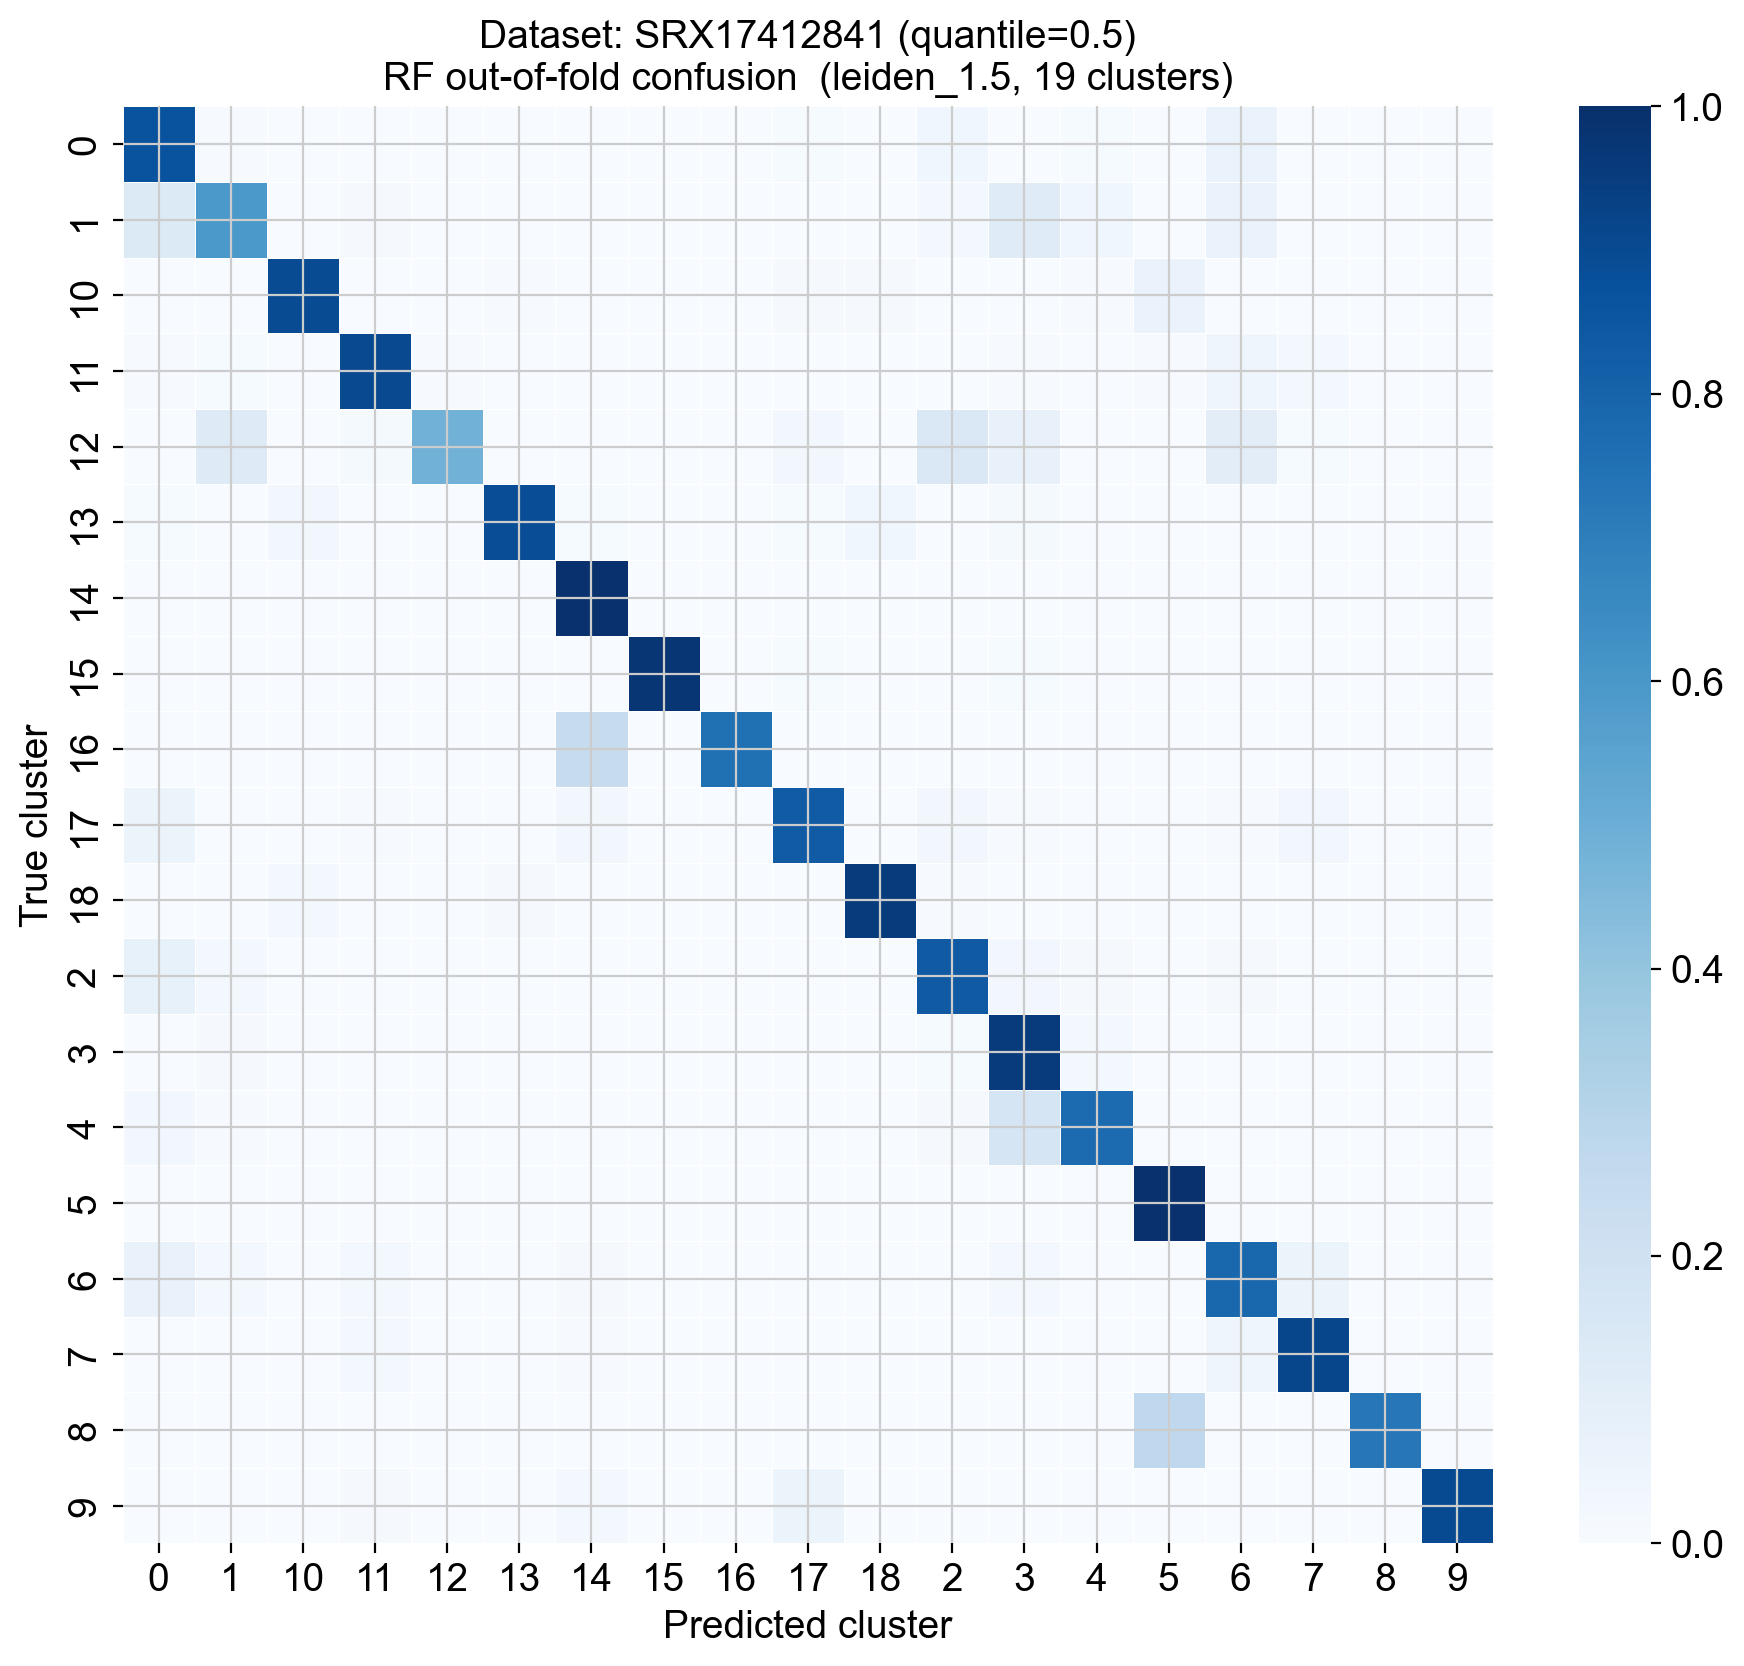

In [83]:
X_hvg = adata.X[:, adata.var.highly_variable.values]
if hasattr(X_hvg, "toarray"):
    X_hvg = X_hvg.toarray()

conf, classes = rf_pairwise_confusion(
    X_hvg,
    adata.obs[CLUSTER_KEY].values,
    weak_prior_labels=(
        adata.obs["cell_type"].values if RF_BALANCE_WEAK_PRIOR else None
    ),
)

fig, ax = plt.subplots(
    figsize=(max(8, len(classes) * 0.5), max(6, len(classes) * 0.45))
)
sns.heatmap(
    conf,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    vmin=0, vmax=1,
    ax=ax,
    # annot=len(classes) <= 25,
    fmt=".2f",
    linewidths=0.3,
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title(
    f"Dataset: {DATASET_TITLE_SUFFIX}\nRF out-of-fold confusion  ({CLUSTER_KEY}, {len(classes)} clusters)"
)
plt.tight_layout()
_save_fig(fig, f".figs/rf_confusion_{DATASET_TAG}.png")
plt.show()

### 6.2 Summarize RF merge

In [84]:
merged_labels, label_map = merge_by_confusion(
    adata.obs[CLUSTER_KEY].values, conf, classes, MERGE_THRESHOLD
)
adata.obs["leiden_merged"] = pd.Categorical(merged_labels)

n_merged = adata.obs["leiden_merged"].nunique()
print(
    f"Before merge : {len(classes)} clusters\n"
    f"After merge  : {n_merged} clusters\n"
    f"k_prior      : {k_prior}\n"
)
label_map_series = pd.Series(label_map, name="merged_into")
print(label_map_series.to_string())

# Print which clusters were merged
merged_groups = {}
for original, merged in label_map.items():
    merged_groups.setdefault(merged, []).append(original)
print("\nClusters merged:")
for merged_label, grouped in merged_groups.items():
    if len(grouped) > 1:
        print(f"{grouped} -> {merged_label}")


Before merge : 19 clusters
After merge  : 17 clusters
k_prior      : 26

0      0
1      1
10     2
11     3
12     4
13     5
14     6
15     7
16     6
17     8
18     9
2     10
3     11
4     12
5     13
6     14
7     15
8     13
9     16

Clusters merged:
['14', '16'] -> 6
['5', '8'] -> 13


## 7. Plot final clustering

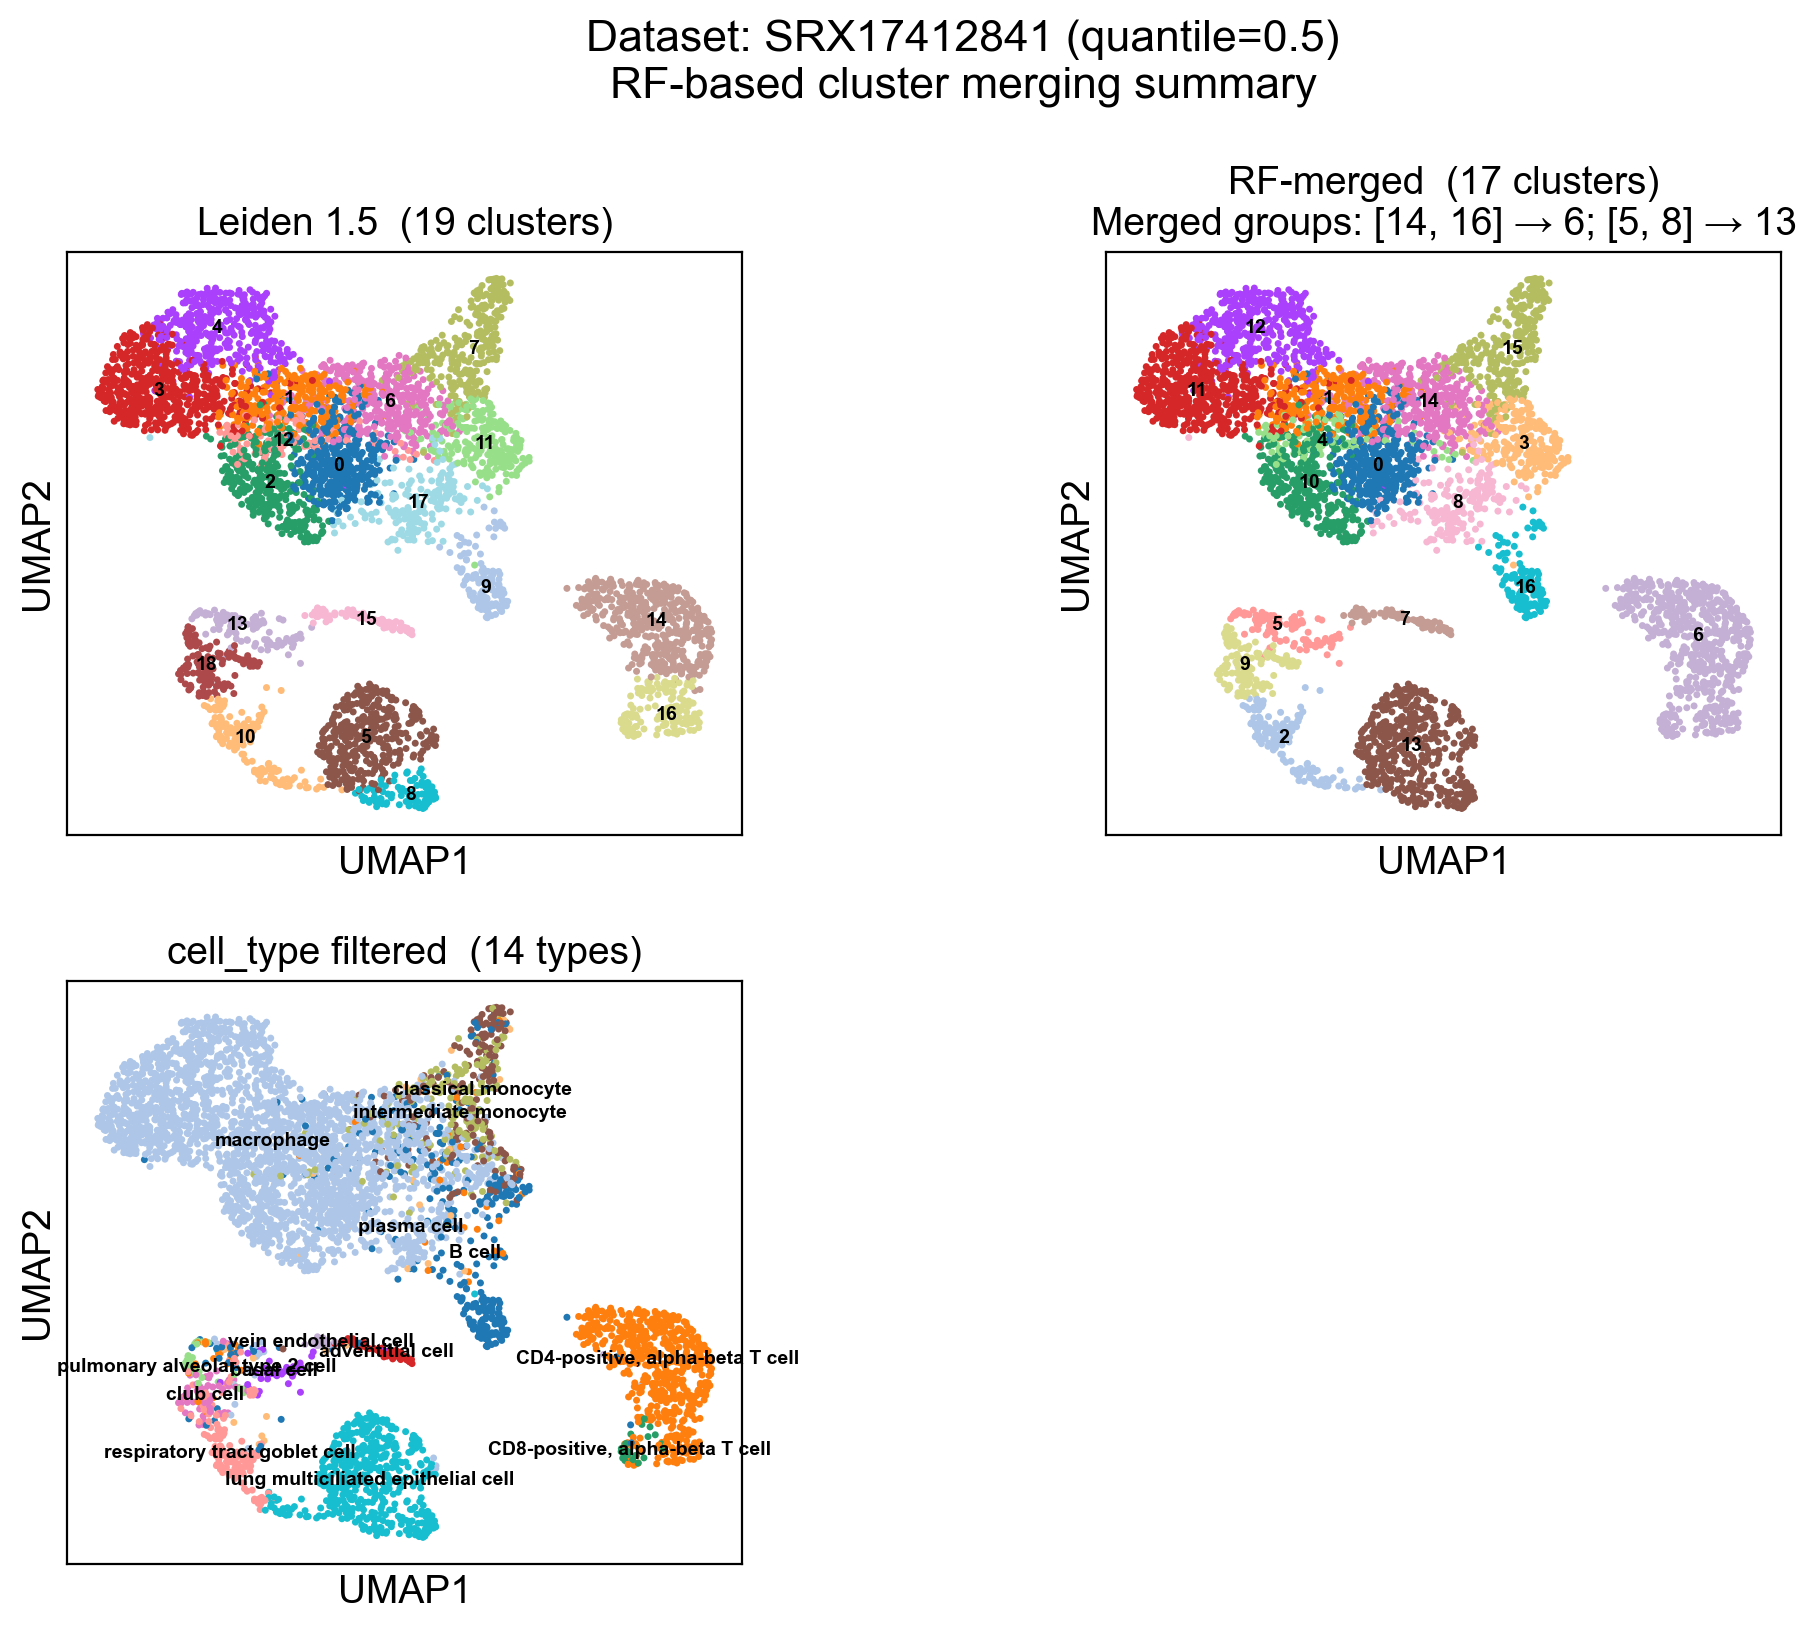

In [85]:
merged_groups_plot = [group for group in merged_groups.values() if len(group) > 1]
if merged_groups_plot:
    merged_groups_str = "; ".join(
        [f"[{', '.join(map(str, g))}] → {m}" for m, g in merged_groups.items() if len(g) > 1]
    )
    umap_merged_title = (
        f"RF-merged  ({n_merged} clusters)\n"
        f"Merged groups: {merged_groups_str}"
    )
else:
    umap_merged_title = f"RF-merged  ({n_merged} clusters)\n(no merges)"
# Regenerate the UMAP plot with merged clusters and new title
fig = sc.pl.umap(
    adata,
    color=[CLUSTER_KEY, "leiden_merged", "cell_type"],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
    title=[
        f"Leiden {SELECTED_RESOLUTION}  ({len(classes)} clusters)",
        umap_merged_title,
        f"cell_type filtered  ({k_filtered} types)",
    ],
    show=False,
    return_fig=True,
)
# Add a main title for the whole plot
if fig is not None:
    fig.suptitle(f"Dataset: {DATASET_TITLE_SUFFIX}\nRF-based cluster merging summary", fontsize=16, y=1.03)

_save_fig(plt.gcf(), f".figs/umap_merged_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

### 7.1 Analyze relative cluster size

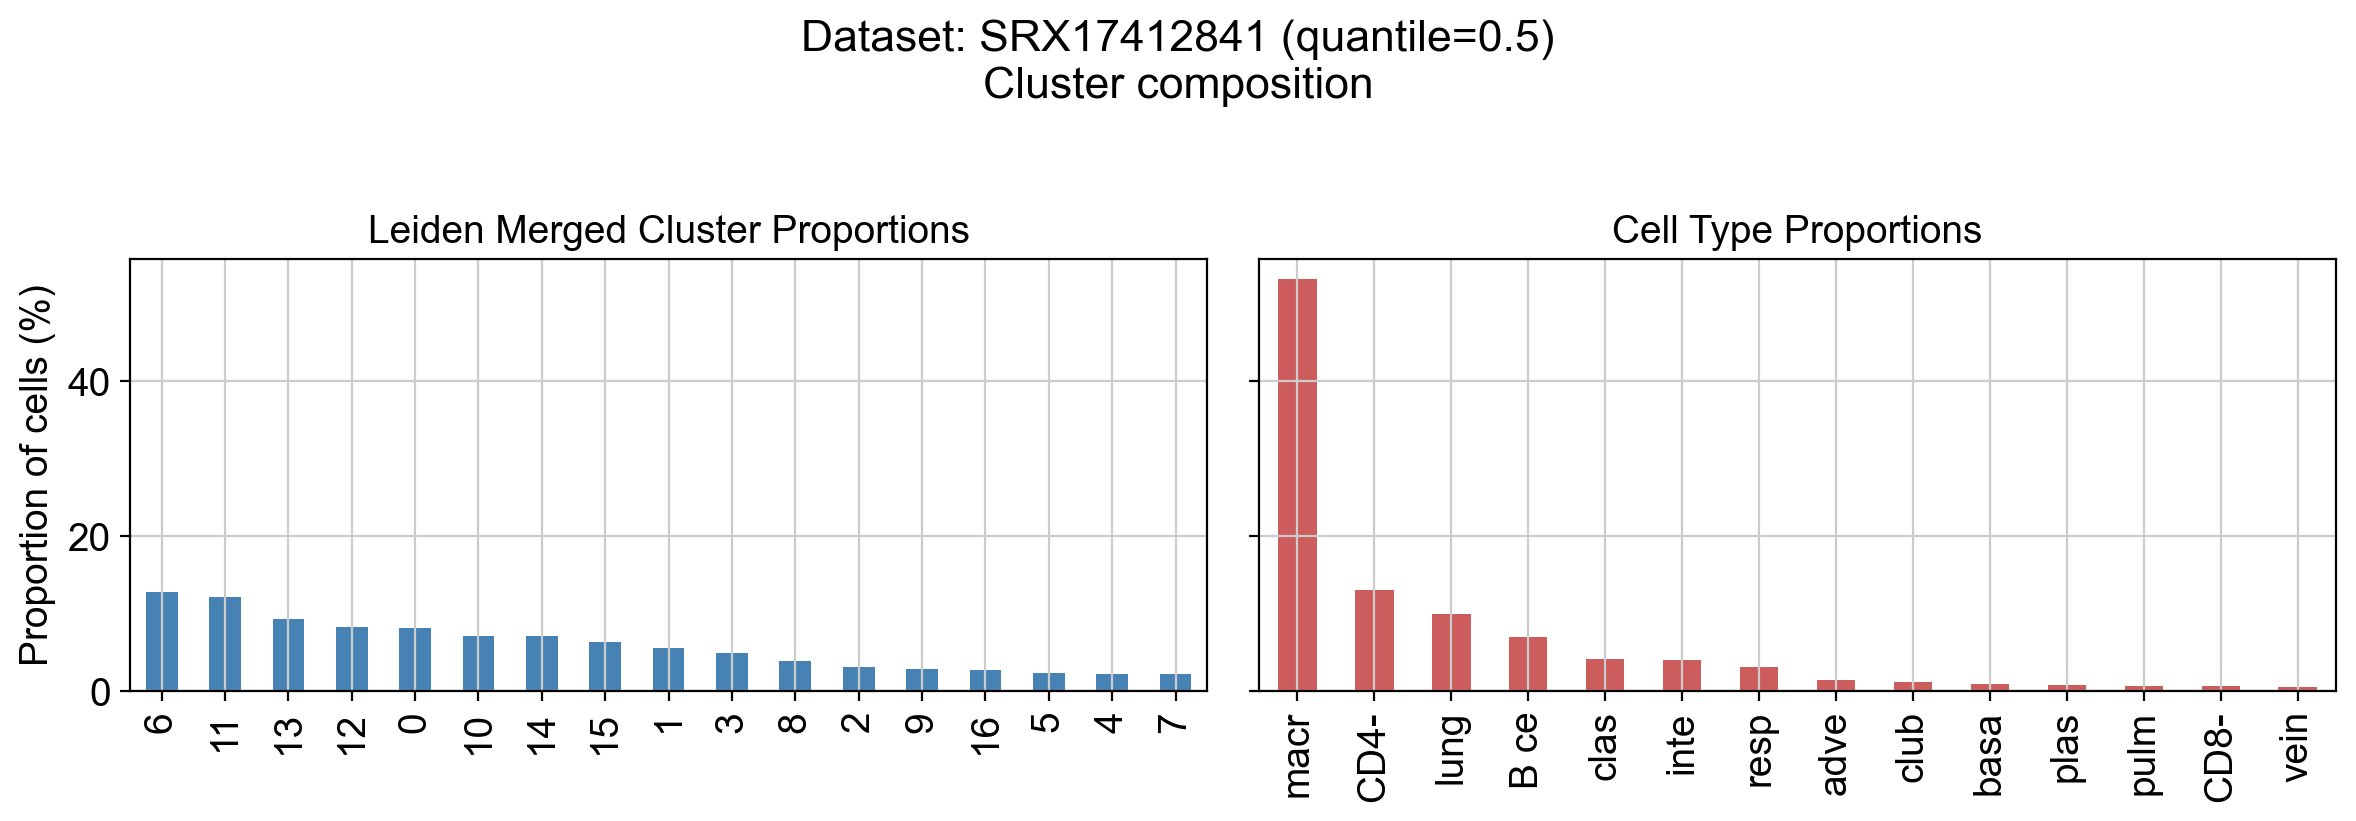

In [86]:
# Calculate normalized value counts and sort by size (descending)
merged_counts = adata.obs["leiden_merged"].value_counts(normalize=True).sort_values(ascending=False) * 100
celltype_counts = adata.obs["cell_type"].value_counts(normalize=True).sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
merged_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Leiden Merged Cluster Proportions")
axes[0].set_ylabel("Proportion of cells (%)")
axes[0].set_xlabel("")
# Show x ticks, limit each label to 4 characters
axes[0].set_xticks(range(len(merged_counts)))
axes[0].set_xticklabels([str(lbl)[:4] for lbl in merged_counts.index], rotation=90)

celltype_counts.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title("Cell Type Proportions")
axes[1].set_xlabel("")
axes[1].set_xticks(range(len(celltype_counts)))
axes[1].set_xticklabels([str(lbl)[:4] for lbl in celltype_counts.index], rotation=90)

fig.suptitle(f"Dataset: {DATASET_TITLE_SUFFIX}\nCluster composition", fontsize=16, y=1.03)

plt.tight_layout()
_save_fig(fig, f".figs/composition_bars_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

## 8. Silhouette/Homogeneity scoring

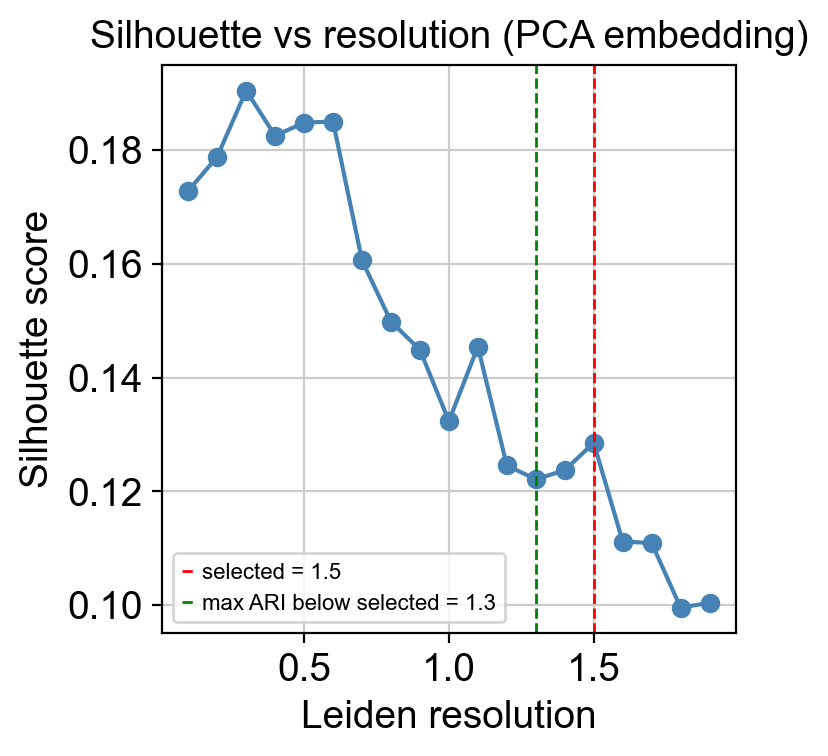

In [87]:
# TODO: compute silhouette score AFTER merging (will require running merge on every resolution)
# Compute silhouette score for all clustering resolutions
silhouette_scores = []
homogeneity_scores = []
completeness_scores = []
nmi = []
vscore = []
ari = []
for i, res in enumerate(RESOLUTIONS):
    cluster_key = f"leiden_{res}" if res != SELECTED_RESOLUTION else CLUSTER_KEY
    labels = adata.obs[cluster_key]
    if labels.nunique() > 1:
        score = silhouette_score(adata.obsm["X_pca"], labels)
        silhouette_scores.append([res, score])
        homogeneity_scores.append([res, homogeneity_score(adata.obs[f"leiden_{res}"], adata.obs["leiden_merged"])])
        completeness_scores.append([res, completeness_score(adata.obs[f"leiden_{res}"], adata.obs["leiden_merged"])])
        nmi.append([res, normalized_mutual_info_score(adata.obs[f"leiden_{res}"], adata.obs["leiden_merged"])])
        vscore.append([res, v_measure_score(adata.obs[f"leiden_{res}"], adata.obs["leiden_merged"])])
        ari.append([res, adjusted_rand_score(adata.obs[f"leiden_{res}"], adata.obs["leiden_merged"])])
silhouette_scores = np.array(silhouette_scores)


fig, ax = plt.subplots()
ax.plot(silhouette_scores[:, 0], silhouette_scores[:, 1], marker="o", color="steelblue")
ax.axvline(
    SELECTED_RESOLUTION,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"selected = {SELECTED_RESOLUTION}",
)
# find max ari index below selected resolution
if SELECTED_RESOLUTION > min(RESOLUTIONS):
    valid_ari = (np.array(ari)[silhouette_scores[:,0] < SELECTED_RESOLUTION])
    max_ari_res = valid_ari[valid_ari[:, 1].argmax(), 0]
    ax.axvline(
        max_ari_res,
        color="green",
        linestyle="--",
        linewidth=1,
        label=f"max ARI below selected = {max_ari_res}",
    )
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette vs resolution (PCA embedding)")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
_save_fig(fig, f".figs/silhouette_vs_resolution_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

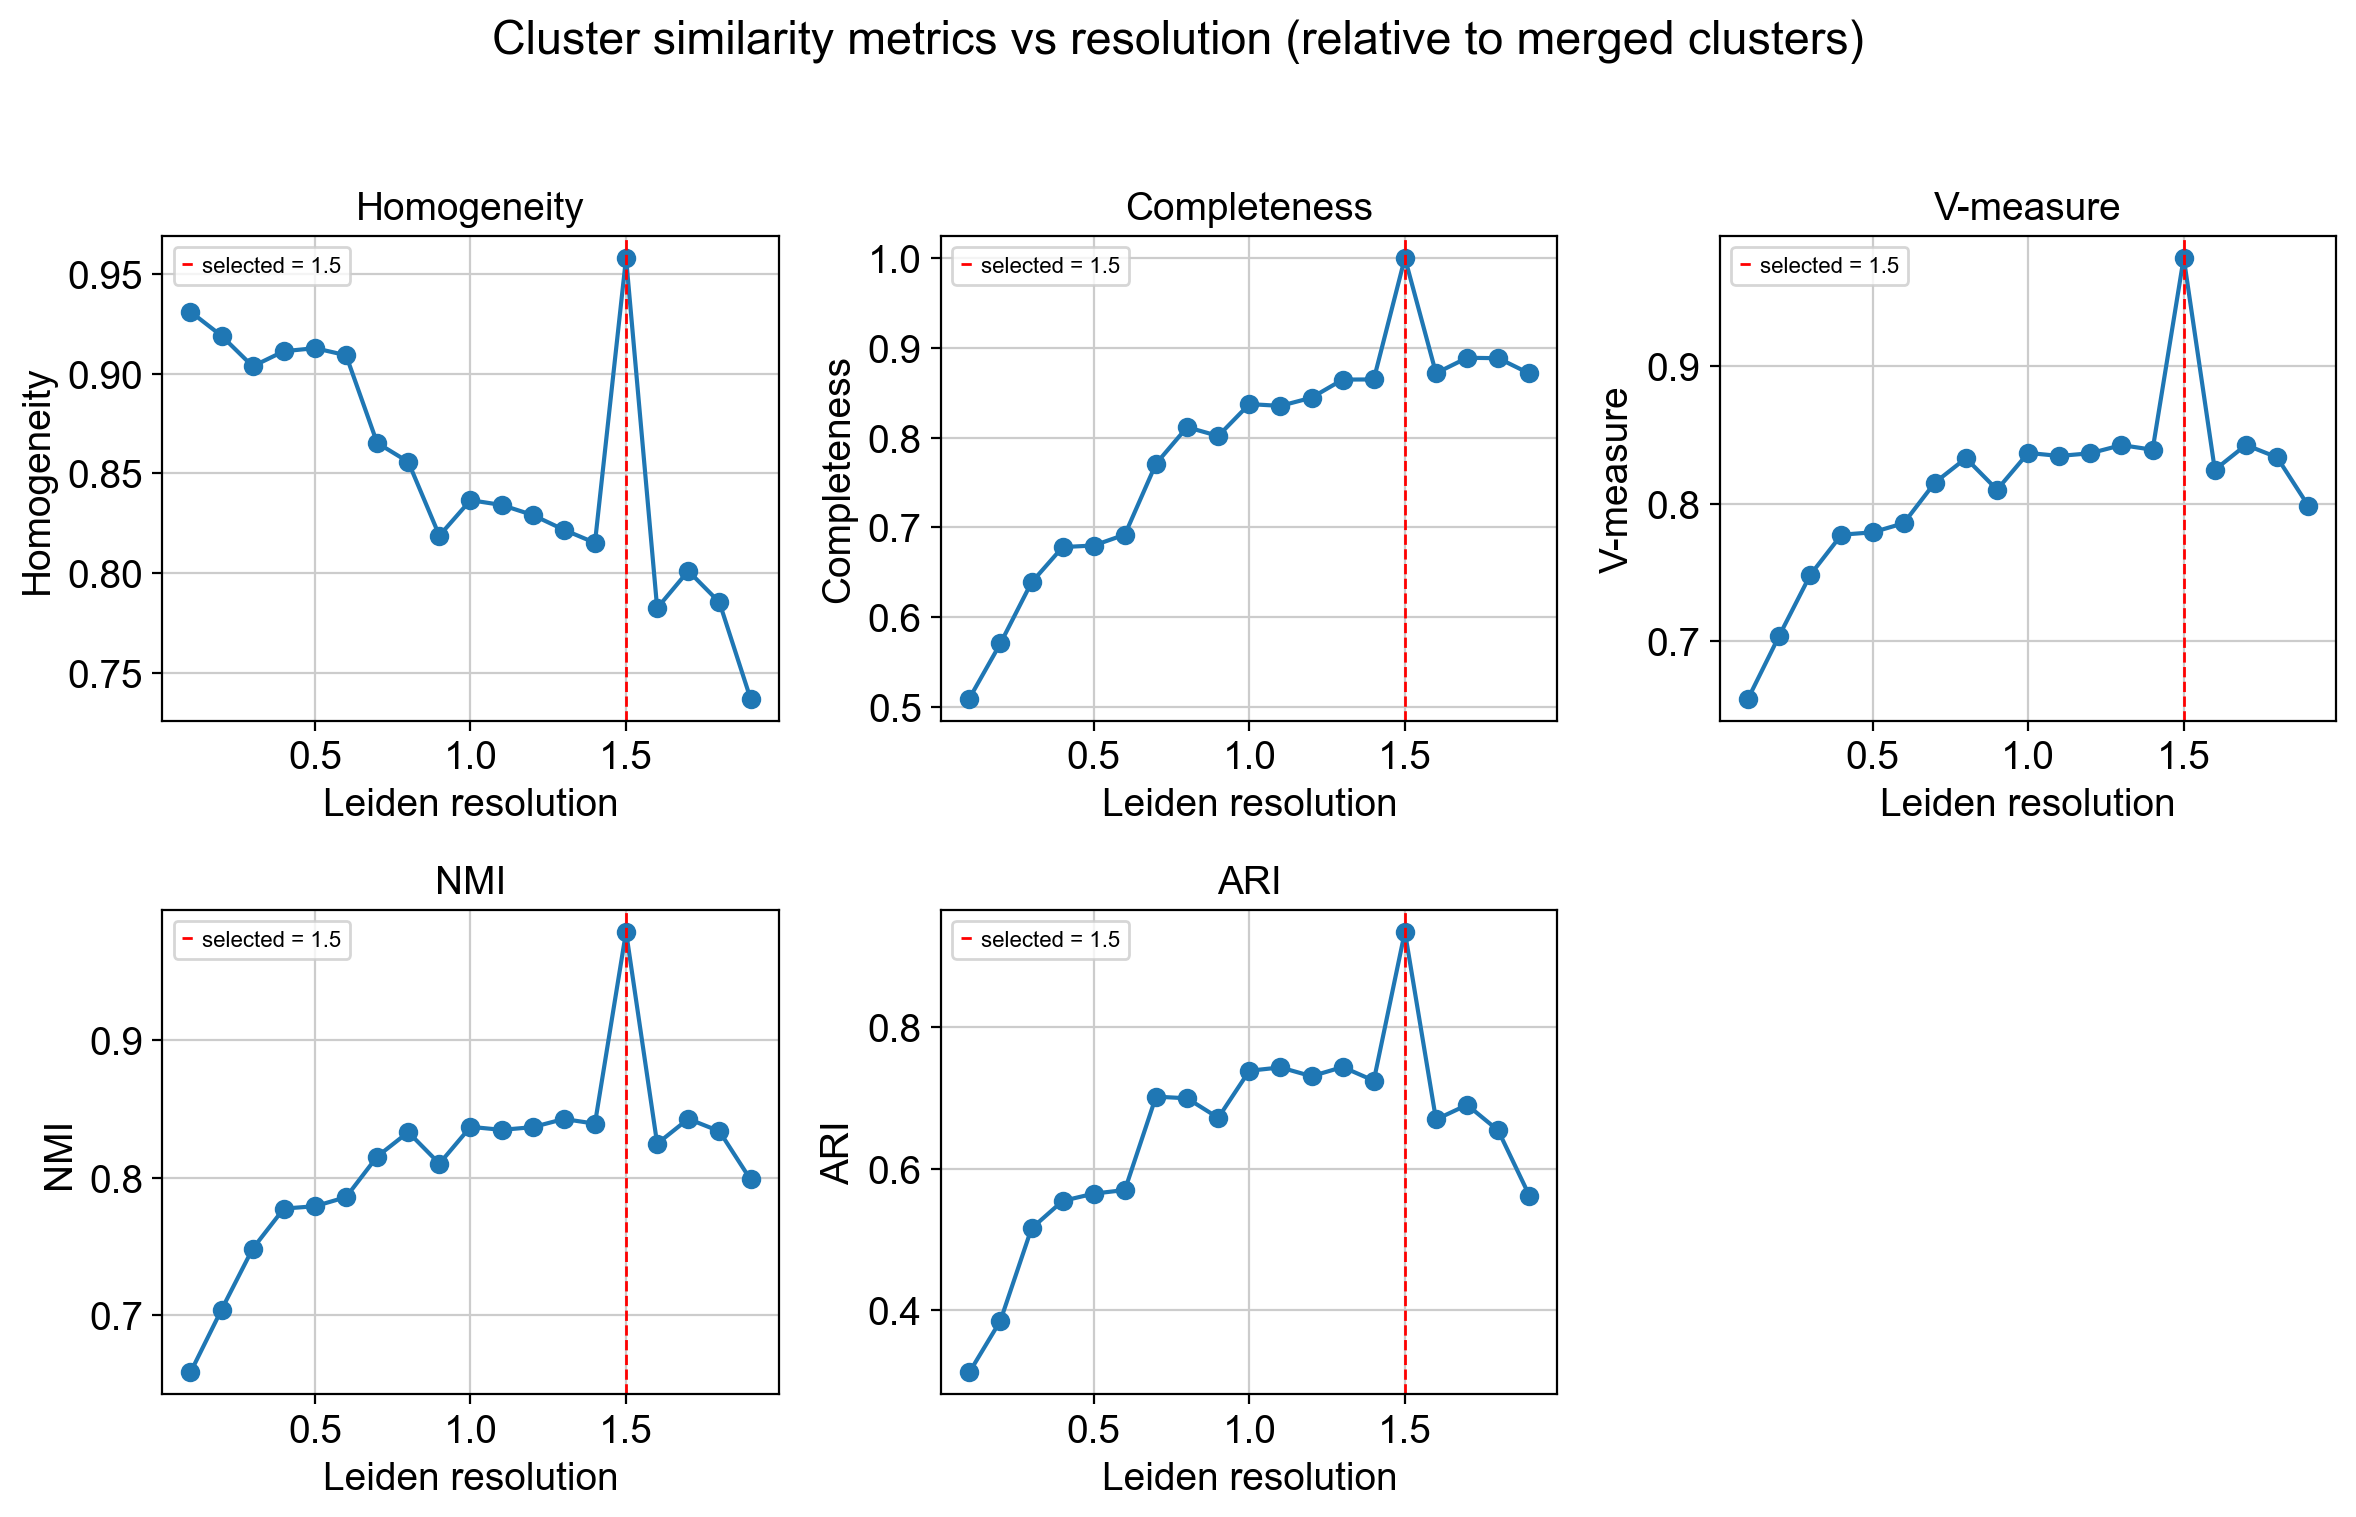

In [88]:
# Convert all metric scores to numpy arrays
homogeneity_scores = np.array(homogeneity_scores)
completeness_scores = np.array(completeness_scores)
nmi = np.array(nmi)
vscore = np.array(vscore)
ari = np.array(ari)

metrics = [
    ("Homogeneity", homogeneity_scores),
    ("Completeness", completeness_scores),
    ("V-measure", vscore),
    ("NMI", nmi),
    ("ARI", ari)
]

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()
for idx, (label, arr) in enumerate(metrics):
    if arr.size > 0:
        axs[idx].plot(arr[:, 0], arr[:, 1], marker='o')
        axs[idx].axvline(
            SELECTED_RESOLUTION, color="red", linestyle="--", linewidth=1, label=f"selected = {SELECTED_RESOLUTION}"
        )
        axs[idx].set_title(label)
        axs[idx].set_xlabel("Leiden resolution")
        axs[idx].set_ylabel(label)
        axs[idx].legend(fontsize=8)
    else:
        axs[idx].set_visible(False)
# Hide the 6th subplot if unused
if len(metrics) < len(axs):
    axs[-1].set_visible(False)

fig.suptitle("Cluster similarity metrics vs resolution (relative to merged clusters)")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(f".figs/homogeneity_completeness_nmi_vscore_ari_vs_resolution_{DATASET_TAG}.png", bbox_inches="tight")
plt.show()

## 9. Save anndata

In [89]:
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path("../data/other")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"final_adata_{DATASET_TAG}.h5ad"
print(f"Saving AnnData to {output_path}...")
adata.write(str(output_path))
print("AnnData saved successfully.")

Saving AnnData to ../data/other/final_adata_SRX17412841.h5ad...
AnnData saved successfully.
